Creating grid and calculating theoretical potential...
Calculating theoretical probability distributions...
Generating plots...


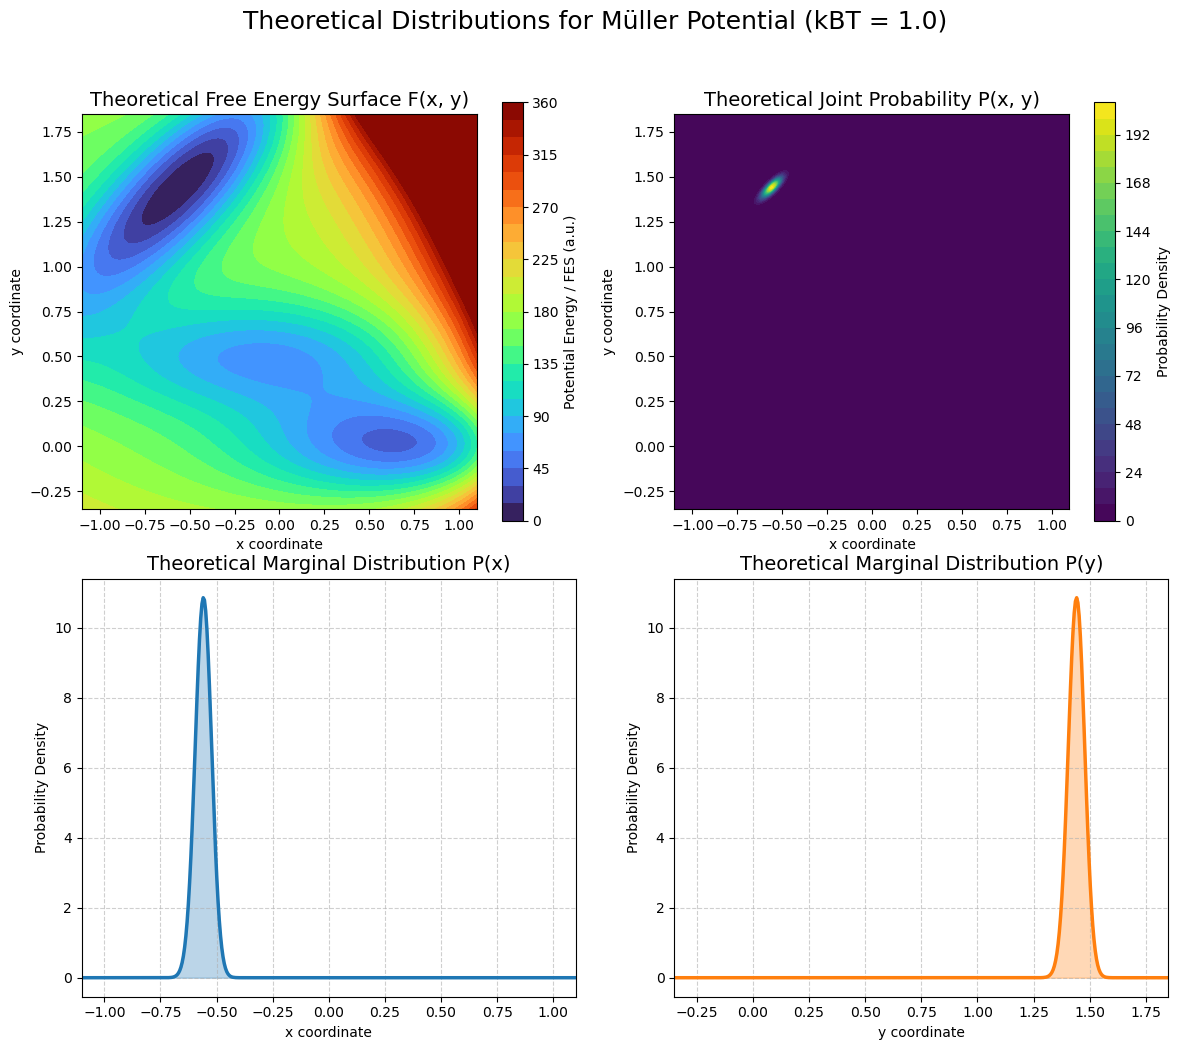

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# PART 1: PARAMETERS AND POTENTIAL FUNCTION
# ==============================================================================

# Your chosen Müller-Brown potential parameters
A = np.array([-200, -100, -170, 15])
a = np.array([-1, -1, -6.5, 0.7])
b = np.array([0, 0, 11, 0.6])
c = np.array([-10, -10, -6.5, 0.7])
x_centers = np.array([1, 0, -0.5, -1])
y_centers = np.array([0, 0.5, 1.5, 1])

# We need to assume a temperature to calculate the Boltzmann distribution.
# We'll use the same value as in our simulation examples.
kBT = 1.0

def muller_potential(x, y):
    """Calculates the Müller-Brown potential at given point(s) (x, y)."""
    value = 0
    for i in range(4):
        value += A[i] * np.exp(a[i] * (x - x_centers[i])**2 +
                               b[i] * (x - x_centers[i]) * (y - y_centers[i]) +
                               c[i] * (y - y_centers[i])**2)
    return value

# ==============================================================================
# PART 2: THEORETICAL CALCULATIONS
# ==============================================================================

# 1. Create a high-resolution grid in the specified domain
print("Creating grid and calculating theoretical potential...")
grid_points = 400
x_grid = np.linspace(-1.1, 1.1, grid_points)
y_grid = np.linspace(-0.35, 1.85, grid_points)
X, Y = np.meshgrid(x_grid, y_grid)

# 2. Calculate the Potential Energy (which is the FES) on the grid
# The theoretical FES is the potential energy itself.
potential_surface = muller_potential(X, Y)
# For easier visualization, we clip the extreme values and set the minimum to 0.
potential_surface = np.clip(potential_surface, -200, 200)
fes_theoretical = potential_surface - np.min(potential_surface)

# 3. Calculate the theoretical joint probability distribution, P(x, y)
print("Calculating theoretical probability distributions...")
# P(x,y) is proportional to exp(-U/kBT)
prob_unnormalized = np.exp(-potential_surface / kBT)

# Normalize the probability distribution. The integral is approximated by a sum
# multiplied by the area of a grid cell (dx * dy).
dx = x_grid[1] - x_grid[0]
dy = y_grid[1] - y_grid[0]
normalization_constant = np.sum(prob_unnormalized) * dx * dy
prob_joint_theoretical = prob_unnormalized / normalization_constant

# 4. Calculate the theoretical marginal distributions, P(x) and P(y)
# P(x) = integral of P(x,y) dy
prob_x_theoretical = np.sum(prob_joint_theoretical, axis=0) * dy
# P(y) = integral of P(x,y) dx
prob_y_theoretical = np.sum(prob_joint_theoretical, axis=1) * dx

# ==============================================================================
# PART 3: PLOTTING THE FOUR THEORETICAL DISTRIBUTIONS
# ==============================================================================

print("Generating plots...")
fig, axes = plt.subplots(2, 2, figsize=(12, 11))
fig.suptitle(f"Theoretical Distributions for Müller Potential (kBT = {kBT})", fontsize=18)
# fig.suptitle("Theoretical Distributions for Müller Potential (kBT = 1.0)", fontsize=18)

# --- Plot 1: Theoretical Free Energy Surface (Top-Left) ---
ax1 = axes[0, 0]
fes_plot = ax1.contourf(X, Y, fes_theoretical, levels=25, cmap='turbo')
fig.colorbar(fes_plot, ax=ax1, label="Potential Energy / FES (a.u.)")
ax1.set_title("Theoretical Free Energy Surface F(x, y)", fontsize=14)
ax1.set_xlabel("x coordinate")
ax1.set_ylabel("y coordinate")
ax1.set_aspect('equal', adjustable='box')

# --- Plot 2: Theoretical Joint Probability Distribution (Top-Right) ---
ax2 = axes[0, 1]
prob_plot = ax2.contourf(X, Y, prob_joint_theoretical, levels=25, cmap='viridis')
fig.colorbar(prob_plot, ax=ax2, label="Probability Density")
ax2.set_title("Theoretical Joint Probability P(x, y)", fontsize=14)
ax2.set_xlabel("x coordinate")
ax2.set_ylabel("y coordinate")
ax2.set_aspect('equal', adjustable='box')

# --- Plot 3: Theoretical Marginal Distribution P(x) (Bottom-Left) ---
ax3 = axes[1, 0]
ax3.plot(x_grid, prob_x_theoretical, lw=2.5, color='C0')
ax3.fill_between(x_grid, prob_x_theoretical, alpha=0.3, color='C0')
ax3.set_title("Theoretical Marginal Distribution P(x)", fontsize=14)
ax3.set_xlabel("x coordinate")
ax3.set_ylabel("Probability Density")
ax3.grid(True, linestyle='--', alpha=0.6)
ax3.set_xlim(x_grid[0], x_grid[-1])

# --- Plot 4: Theoretical Marginal Distribution P(y) (Bottom-Right) ---
ax4 = axes[1, 1]
ax4.plot(y_grid, prob_y_theoretical, lw=2.5, color='C1')
ax4.fill_between(y_grid, prob_y_theoretical, alpha=0.3, color='C1')
ax4.set_title("Theoretical Marginal Distribution P(y)", fontsize=14)
ax4.set_xlabel("y coordinate")
ax4.set_ylabel("Probability Density")
ax4.grid(True, linestyle='--', alpha=0.6)
ax4.set_xlim(y_grid[0], y_grid[-1])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Creating grid and calculating theoretical potential...
Calculating theoretical probability distributions...
Generating plots...


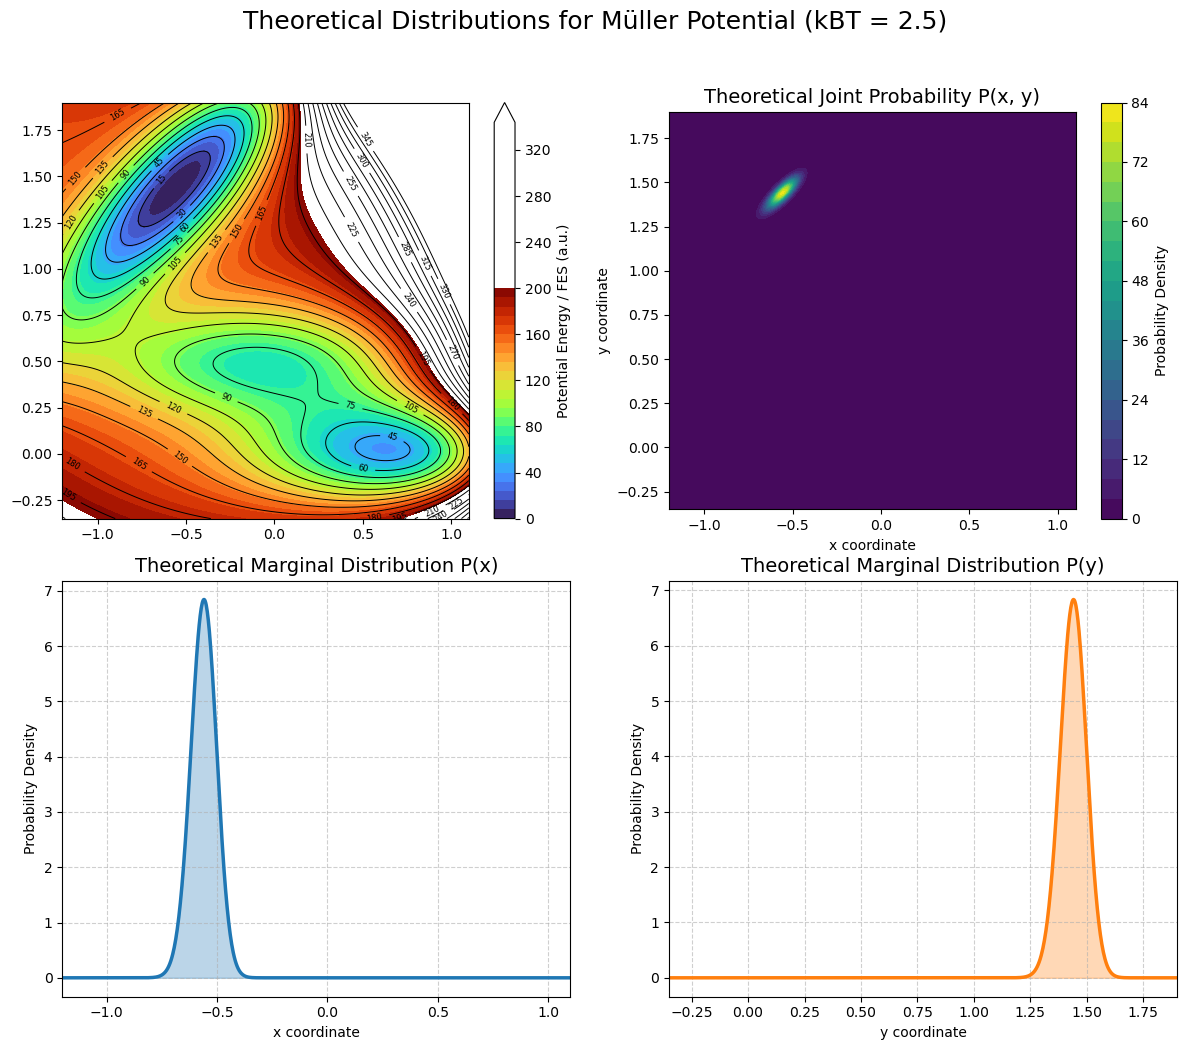

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ==============================================================================
# PART 1: PARAMETERS AND POTENTIAL FUNCTION
# ==============================================================================

# Your chosen Müller-Brown potential parameters
A = np.array([-200, -100, -170, 15])
a = np.array([-1, -1, -6.5, 0.7])
b = np.array([0, 0, 11, 0.6])
c = np.array([-10, -10, -6.5, 0.7])
x_centers = np.array([1, 0, -0.5, -1])
y_centers = np.array([0, 0.5, 1.5, 1])

# We need to assume a temperature to calculate the Boltzmann distribution.
# We'll use the same value as in our simulation examples.
kBT = 2.5

def muller_potential(x, y):
    """Calculates the Müller-Brown potential at given point(s) (x, y)."""
    value = 0
    for i in range(4):
        value += A[i] * np.exp(a[i] * (x - x_centers[i])**2 +
                               b[i] * (x - x_centers[i]) * (y - y_centers[i]) +
                               c[i] * (y - y_centers[i])**2)
    return value

# ==============================================================================
# PART 2: THEORETICAL CALCULATIONS
# ==============================================================================

# 1. Create a high-resolution grid in the specified domain
print("Creating grid and calculating theoretical potential...")
grid_points = 1000
x_grid = np.linspace(-1.2, 1.1, grid_points)
y_grid = np.linspace(-0.35, 1.9, grid_points)
X, Y = np.meshgrid(x_grid, y_grid)

# 2. Calculate the Potential Energy (which is the FES) on the grid
# The theoretical FES is the potential energy itself.
potential_surface = muller_potential(X, Y)
# For easier visualization, we clip the extreme values and set the minimum to 0.
potential_surface = np.clip(potential_surface, -200, 200)
fes_theoretical = potential_surface - np.min(potential_surface)

# 3. Calculate the theoretical joint probability distribution, P(x, y)
print("Calculating theoretical probability distributions...")
# P(x,y) is proportional to exp(-U/kBT)
prob_unnormalized = np.exp(-potential_surface / kBT)

# Normalize the probability distribution. The integral is approximated by a sum
# multiplied by the area of a grid cell (dx * dy).
dx = x_grid[1] - x_grid[0]
dy = y_grid[1] - y_grid[0]
normalization_constant = np.sum(prob_unnormalized) * dx * dy
prob_joint_theoretical = prob_unnormalized / normalization_constant

# 4. Calculate the theoretical marginal distributions, P(x) and P(y)
# P(x) = integral of P(x,y) dy
prob_x_theoretical = np.sum(prob_joint_theoretical, axis=0) * dy
# P(y) = integral of P(x,y) dx
prob_y_theoretical = np.sum(prob_joint_theoretical, axis=1) * dx

# ==============================================================================
# PART 3: PLOTTING THE FOUR THEORETICAL DISTRIBUTIONS
# ==============================================================================

print("Generating plots...")
fig, axes = plt.subplots(2, 2, figsize=(12, 11))
fig.suptitle(f"Theoretical Distributions for Müller Potential (kBT = {kBT})", fontsize=18)
# fig.suptitle("Theoretical Distributions for Müller Potential (kBT = 1.0)", fontsize=18)

# --- Plot 1: Theoretical Free Energy Surface (Top-Left) ---
ax1 = axes[0, 0]
clip_threshold = 200
potential_surface = np.clip(potential_surface, -200, clip_threshold)
fes_theoretical = potential_surface - np.min(potential_surface)

# 创建 colormap 并设置超过 clip_threshold 的区域颜色
cmap = plt.get_cmap('turbo').copy()
cmap.set_over('white')  # 超出最大值部分用白色表示

# 设置颜色归一化范围（0 到 clip_threshold），并允许 "extend"
norm = mcolors.Normalize(vmin=0, vmax=clip_threshold)

# --- Plot 1: 修改这一段 ---
fes_plot = ax1.contourf(X, Y, fes_theoretical, levels=50, cmap=cmap, norm=norm, extend='max')
fig.colorbar(fes_plot, ax=ax1, label="Potential Energy / FES (a.u.)", extend='max')
contour_lines = ax1.contour(X, Y, fes_theoretical, levels=25, colors='black', linewidths=0.7)
ax1.clabel(contour_lines, inline=True, fontsize=6, fmt="%.0f")

# --- Plot 2: Theoretical Joint Probability Distribution (Top-Right) ---
ax2 = axes[0, 1]
prob_plot = ax2.contourf(X, Y, prob_joint_theoretical, levels=25, cmap='viridis')
fig.colorbar(prob_plot, ax=ax2, label="Probability Density")
ax2.set_title("Theoretical Joint Probability P(x, y)", fontsize=14)
ax2.set_xlabel("x coordinate")
ax2.set_ylabel("y coordinate")
ax2.set_aspect('equal', adjustable='box')

# --- Plot 3: Theoretical Marginal Distribution P(x) (Bottom-Left) ---
ax3 = axes[1, 0]
ax3.plot(x_grid, prob_x_theoretical, lw=2.5, color='C0')
ax3.fill_between(x_grid, prob_x_theoretical, alpha=0.3, color='C0')
ax3.set_title("Theoretical Marginal Distribution P(x)", fontsize=14)
ax3.set_xlabel("x coordinate")
ax3.set_ylabel("Probability Density")
ax3.grid(True, linestyle='--', alpha=0.6)
ax3.set_xlim(x_grid[0], x_grid[-1])

# --- Plot 4: Theoretical Marginal Distribution P(y) (Bottom-Right) ---
ax4 = axes[1, 1]
ax4.plot(y_grid, prob_y_theoretical, lw=2.5, color='C1')
ax4.fill_between(y_grid, prob_y_theoretical, alpha=0.3, color='C1')
ax4.set_title("Theoretical Marginal Distribution P(y)", fontsize=14)
ax4.set_xlabel("y coordinate")
ax4.set_ylabel("Probability Density")
ax4.grid(True, linestyle='--', alpha=0.6)
ax4.set_xlim(y_grid[0], y_grid[-1])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [5]:
MULLER_A = np.array([-200, -100, -170, 15])
MULLER_a = np.array([-1, -1, -6.5, 0.7])
MULLER_b = np.array([0, 0, 11, 0.6])
MULLER_c = np.array([-10, -10, -6.5, 0.7])
MULLER_x0 = np.array([1, 0, -0.5, -1])
MULLER_y0 = np.array([0, 0.5, 1.5, 1])

def muller_potential(x, y):
    """
    标准的 Muller 势能函数
    V(x,y) = sum( A_i * exp( a_i*(x-x0_i)^2 + b_i*(x-x0_i)*(y-y0_i) + c_i*(y-y0_i)^2 ) )
    """
    V = 0.0
    # 循环累加 4 个高斯项
    for i in range(4):
        dx = x - MULLER_x0[i]
        dy = y - MULLER_y0[i]
        
        # 指数部分: a(dx)^2 + b(dx)(dy) + c(dy)^2
        exponent = (MULLER_a[i] * dx**2 + 
                    MULLER_b[i] * dx * dy + 
                    MULLER_c[i] * dy**2)
        
        V += MULLER_A[i] * np.exp(exponent)
        
    return V

def dV_muller_analytical(x, y):
    """
    Muller 势能的解析梯度
    Returns:
    --------
    grad : array [dV/dx, dV/dy]
    """
    scalar_input = np.isscalar(x) and np.isscalar(y)

    if scalar_input:
        x_arr = np.array([x])
        y_arr = np.array([y])
    else:
        x_arr = x
        y_arr = y

    # 初始化梯度
    dV_dx = np.zeros_like(x_arr, dtype=float)
    dV_dy = np.zeros_like(y_arr, dtype=float)

    # 循环计算每一项的梯度并累加
    # 链式法则: d(A * exp(U))/dx = A * exp(U) * dU/dx
    for i in range(4):
        dx = x_arr - MULLER_x0[i]
        dy = y_arr - MULLER_y0[i]
        
        # 1. 计算指数部分 U 和 exp(U)
        exponent = (MULLER_a[i] * dx**2 + 
                    MULLER_b[i] * dx * dy + 
                    MULLER_c[i] * dy**2)
        
        exp_term = np.exp(exponent)
        term_val = MULLER_A[i] * exp_term  # 当前项的势能值
        
        # 2. 计算指数 U 对 x 的导数: dU/dx = 2*a*dx + b*dy
        dU_dx = 2 * MULLER_a[i] * dx + MULLER_b[i] * dy
        
        # 3. 计算指数 U 对 y 的导数: dU/dy = b*dx + 2*c*dy
        dU_dy = MULLER_b[i] * dx + 2 * MULLER_c[i] * dy
        
        # 4. 累加梯度
        dV_dx += term_val * dU_dx
        dV_dy += term_val * dU_dy

    # 堆叠结果
    grad = np.stack([dV_dx, dV_dy], axis=-1)

    return grad[0] if scalar_input else grad

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_well_weights(kT, x_range=(-1.1, 1.1), y_range=(-0.3, 1.8), n_grid=200):
    """
    计算Müller势能在给定温度下，不同势井的玻尔兹曼权重分布
    
    参数:
        kT: 温度
        x_range: x坐标范围 (x_min, x_max)
        y_range: y坐标范围 (y_min, y_max)
        n_grid: 网格分辨率
    
    返回:
        weights: 字典，包含 'left', 'middle', 'right' 的权重
        grid_data: 字典，包含网格信息（用于可视化）
    """
    # 创建网格
    x_grid = np.linspace(x_range[0], x_range[1], n_grid)
    y_grid = np.linspace(y_range[0], y_range[1], n_grid)
    X, Y = np.meshgrid(x_grid, y_grid)
    
    # 计算势能
    V = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            V[i, j] = muller_potential(X[i, j], Y[i, j])
    
    # 计算玻尔兹曼分布 P(x,y) ∝ exp(-V/kT)
    boltzmann = np.exp(-V / kT)
    
    # 网格面积元
    dx = (x_range[1] - x_range[0]) / n_grid
    dy = (y_range[1] - y_range[0]) / n_grid
    dA = dx * dy
    
    # 归一化常数
    Z = np.sum(boltzmann) * dA
    prob = boltzmann / Z
    
    # 分区域计算权重
    # Left well: x < -0.25
    mask_left = X < -0.25
    weight_left = np.sum(prob[mask_left]) * dA
    
    # Middle well: -0.25 <= x <= 0.25
    mask_middle = (X >= -0.25) & (X <= 0.25)
    weight_middle = np.sum(prob[mask_middle]) * dA
    
    # Right well: x > 0.25
    mask_right = X > 0.25
    weight_right = np.sum(prob[mask_right]) * dA
    
    # 总权重（应该接近1）
    total = weight_left + weight_middle + weight_right
    
    weights = {
        'left': weight_left,
        'middle': weight_middle,
        'right': weight_right,
        'total': total
    }
    
    grid_data = {
        'X': X,
        'Y': Y,
        'V': V,
        'prob': prob,
        'mask_left': mask_left,
        'mask_middle': mask_middle,
        'mask_right': mask_right
    }
    
    return weights, grid_data


def print_well_weights(kT):
    """打印不同温度下的势井权重"""
    weights, _ = calculate_well_weights(kT)
    
    print(f"\n{'='*60}")
    print(f"温度 kT = {kT}")
    print(f"{'='*60}")
    print(f"左势井 (x < -0.25):     {weights['left']:.4f}  ({weights['left']*100:.2f}%)")
    print(f"中势井 (-0.25 ≤ x ≤ 0.25): {weights['middle']:.4f}  ({weights['middle']*100:.2f}%)")
    print(f"右势井 (x > 0.25):     {weights['right']:.4f}  ({weights['right']*100:.2f}%)")
    print(f"总和:                  {weights['total']:.4f}")
    print(f"{'='*60}\n")
    
    return weights


def visualize_well_distribution(kT, show_prob=True):
    """
    可视化不同势井的分布
    
    参数:
        kT: 温度
        show_prob: 是否显示概率密度（否则显示势能）
    """
    weights, grid_data = calculate_well_weights(kT)
    
    X = grid_data['X']
    Y = grid_data['Y']
    V = grid_data['V']
    prob = grid_data['prob']
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 第1图：势能面 + 分界线
    ax1 = axes[0]
    contour = ax1.contourf(X, Y, V, levels=40, cmap='viridis')
    plt.colorbar(contour, ax=ax1, label='Potential Energy')
    ax1.axvline(-0.25, color='red', linestyle='--', linewidth=2, label='Left | Middle')
    ax1.axvline(0.25, color='orange', linestyle='--', linewidth=2, label='Middle | Right')
    ax1.set_xlabel('x', fontsize=12)
    ax1.set_ylabel('y', fontsize=12)
    ax1.set_title(f'Müller Potential (kT={kT})', fontsize=14)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 第2图：概率分布
    ax2 = axes[1]
    if show_prob:
        contour2 = ax2.contourf(X, Y, prob, levels=40, cmap='hot')
        plt.colorbar(contour2, ax=ax2, label='Probability Density')
        title2 = 'Boltzmann Distribution'
    else:
        contour2 = ax2.contourf(X, Y, np.exp(-V/kT), levels=40, cmap='hot')
        plt.colorbar(contour2, ax=ax2, label='exp(-V/kT)')
        title2 = 'Boltzmann Factor'
    
    ax2.axvline(-0.25, color='cyan', linestyle='--', linewidth=2, alpha=0.8)
    ax2.axvline(0.25, color='cyan', linestyle='--', linewidth=2, alpha=0.8)
    ax2.set_xlabel('x', fontsize=12)
    ax2.set_ylabel('y', fontsize=12)
    ax2.set_title(title2, fontsize=14)
    ax2.grid(True, alpha=0.3)
    
    # 第3图：分区域着色
    ax3 = axes[2]
    colored_prob = np.zeros_like(prob)
    colored_prob[grid_data['mask_left']] = prob[grid_data['mask_left']]
    colored_prob[grid_data['mask_middle']] = prob[grid_data['mask_middle']] * 2  # 中间势井用不同颜色
    colored_prob[grid_data['mask_right']] = prob[grid_data['mask_right']] * 3   # 右边势井用不同颜色
    
    # 分别绘制三个区域
    ax3.contourf(X, Y, V, levels=30, cmap='gray', alpha=0.3)
    
    # 用不同颜色填充三个区域
    ax3.contourf(X, Y, grid_data['mask_left'], levels=[0.5, 1.5], colors=['blue'], alpha=0.3)
    ax3.contourf(X, Y, grid_data['mask_middle'], levels=[0.5, 1.5], colors=['orange'], alpha=0.3)
    ax3.contourf(X, Y, grid_data['mask_right'], levels=[0.5, 1.5], colors=['green'], alpha=0.3)
    
    ax3.axvline(-0.25, color='red', linestyle='--', linewidth=2)
    ax3.axvline(0.25, color='red', linestyle='--', linewidth=2)
    
    # 添加文字标签
    ax3.text(-0.65, 1.5, f'Left\n{weights["left"]*100:.1f}%', 
            fontsize=14, fontweight='bold', ha='center', 
            bbox=dict(boxstyle='round', facecolor='blue', alpha=0.5))
    ax3.text(0.0, 0.5, f'Middle\n{weights["middle"]*100:.1f}%', 
            fontsize=14, fontweight='bold', ha='center',
            bbox=dict(boxstyle='round', facecolor='orange', alpha=0.5))
    ax3.text(0.65, 0.0, f'Right\n{weights["right"]*100:.1f}%', 
            fontsize=14, fontweight='bold', ha='center',
            bbox=dict(boxstyle='round', facecolor='green', alpha=0.5))
    
    ax3.set_xlabel('x', fontsize=12)
    ax3.set_ylabel('y', fontsize=12)
    ax3.set_title('Well Regions & Weights', fontsize=14)
    ax3.grid(True, alpha=0.3)
    
    plt.show()


def compare_temperatures(kT_list):
    """
    比较不同温度下的势井权重
    
    参数:
        kT_list: 温度列表
    """
    print(f"\n{'='*80}")
    print(f"不同温度下的势井权重对比")
    print(f"{'='*80}")
    print(f"{'kT':>6s} {'Left (%)':>12s} {'Middle (%)':>12s} {'Right (%)':>12s} {'Total':>8s}")
    print(f"{'-'*80}")
    
    results = []
    for kT in kT_list:
        weights, _ = calculate_well_weights(kT)
        results.append(weights)
        print(f"{kT:6.1f} {weights['left']*100:11.2f}% {weights['middle']*100:11.2f}% "
              f"{weights['right']*100:11.2f}% {weights['total']:8.4f}")
    
    print(f"{'='*80}\n")
    
    # 绘制柱状图
    fig, ax = plt.subplots(figsize=(10, 6))
    
    x = np.arange(len(kT_list))
    width = 0.25
    
    left_weights = [r['left']*100 for r in results]
    middle_weights = [r['middle']*100 for r in results]
    right_weights = [r['right']*100 for r in results]
    
    ax.bar(x - width, left_weights, width, label='Left well', color='blue', alpha=0.7)
    ax.bar(x, middle_weights, width, label='Middle well', color='orange', alpha=0.7)
    ax.bar(x + width, right_weights, width, label='Right well', color='green', alpha=0.7)
    
    ax.set_xlabel('Temperature (kT)', fontsize=12)
    ax.set_ylabel('Weight (%)', fontsize=12)
    ax.set_title('Well Weights at Different Temperatures', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{kT}' for kT in kT_list])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    

    plt.show()
    
    return results



In [9]:
weights = print_well_weights(kT=2.5)


温度 kT = 2.5
左势井 (x < -0.25):     1.0000  (100.00%)
中势井 (-0.25 ≤ x ≤ 0.25): 0.0000  (0.00%)
右势井 (x > 0.25):     0.0000  (0.00%)
总和:                  1.0000



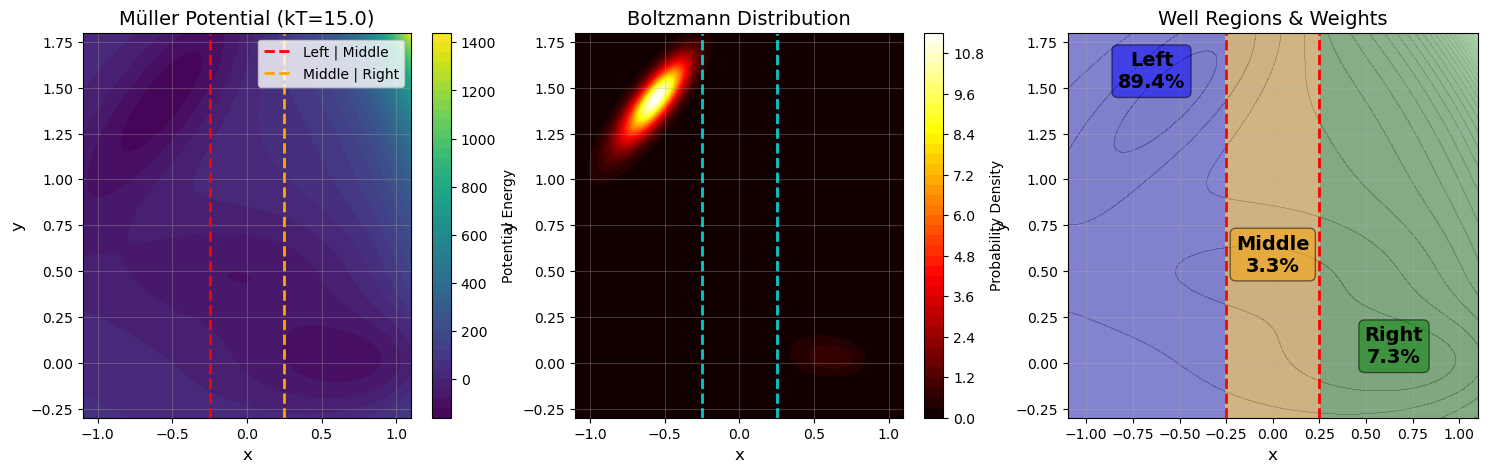

In [11]:
visualize_well_distribution(kT=15.0)

Saved: muller_potential_paper.png


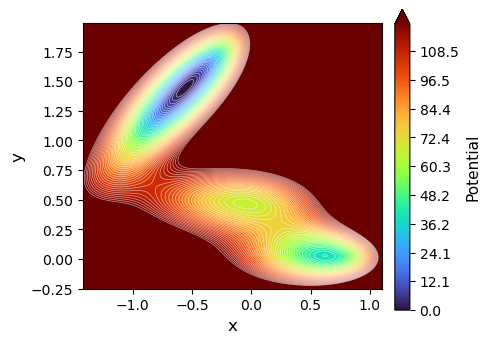

In [4]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_muller_potential_paper(
    x_range=(-1.42, 1.1),
    y_range=(-0.25, 1.99),
    n_grid=800,
    v_cap=120,
    n_contour=60,
    figsize=(5, 5),
    save_path=None,
):
    x_grid = np.linspace(x_range[0], x_range[1], n_grid)
    y_grid = np.linspace(y_range[0], y_range[1], n_grid)
    X, Y = np.meshgrid(x_grid, y_grid)

    V = muller_potential(X, Y)
    V_shifted = V - V.min()

    cmap = plt.get_cmap('turbo').copy()
    cmap.set_over('#6b0000')
    norm = mcolors.Normalize(vmin=0, vmax=v_cap)

    fig, ax = plt.subplots(figsize=figsize)

    cf = ax.contourf(X, Y, V_shifted,
                     levels=np.linspace(0, v_cap, 200),
                     cmap=cmap, norm=norm, extend='max')

    ax.contour(X, Y, V_shifted,
               levels=np.linspace(0, v_cap, n_contour),
               colors='white', linewidths=0.5, alpha=0.6)

    cbar = fig.colorbar(cf, ax=ax, extend='max', fraction=0.046, pad=0.04)
    cbar.set_label('Potential', fontsize=11)

    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('y', fontsize=12)
    ax.set_aspect('equal')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")

    plt.show()


plot_muller_potential_paper(save_path='muller_potential_paper.png')


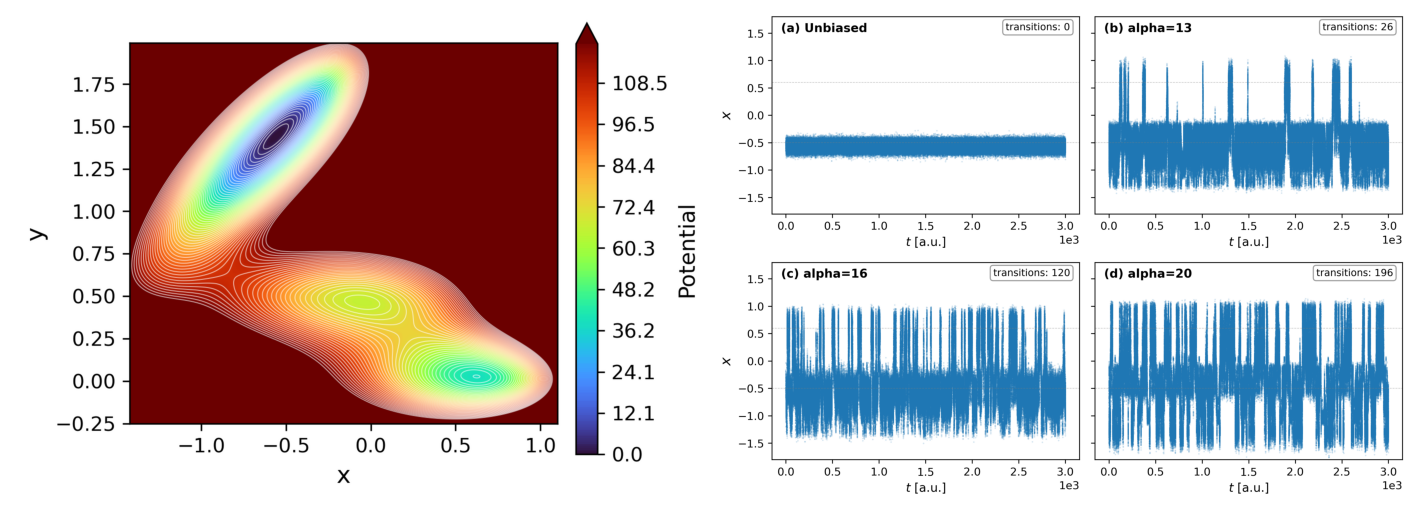

Saved: muller_combined.png


In [5]:

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# 加载两张图
left_img = Image.open('muller_potential_paper.png')
right_img = Image.open('muller_num_transit.png')

# 让左图高度和右图一致（保持宽高比缩放）
target_h = right_img.height
scale = target_h / left_img.height
new_w = int(left_img.width * scale)
left_img_resized = left_img.resize((new_w, target_h), Image.LANCZOS)

# 拼接
total_w = new_w + right_img.width
combined = Image.new('RGB', (total_w, target_h), (255, 255, 255))
combined.paste(left_img_resized, (0, 0))
combined.paste(right_img, (new_w, 0))

# 显示并保存
fig, ax = plt.subplots(figsize=(14, 14 * target_h / total_w))
ax.imshow(np.array(combined))
ax.axis('off')
plt.tight_layout(pad=0)
plt.savefig('muller_combined.png', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()
print("Saved: muller_combined.png")
